<a href="https://colab.research.google.com/github/alexandrebarbosa-dev/desafioTelecomX_BR/blob/main/TelecomX_BR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PY

shape inicial: (7267, 21)
shape após limpeza: (7043, 21)

Taxa geral de churn:
Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64

Evasão por contrato:
Contrato
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: object

Evasão por suporte:
Suporte
No                     0.416355
No internet service     0.07405
Yes                    0.151663
Name: Churn, dtype: object

Churn por faixa de tempo:
Churn               0         1
Faixa_Tempo                    
0-12         0.517158  0.482842
12-24        0.704871  0.295129
24-36        0.779680  0.220320
36-60        0.828444  0.171556
60+          0.933243  0.066757

Média de Evasão mensal :
Churn
0    37.569965
1    17.979133
Name: Meses, dtype: float64

Média de gasto total de Evasão:
Churn
0    2549.911442
1    1531.796094
Name: Total, dtype: float64


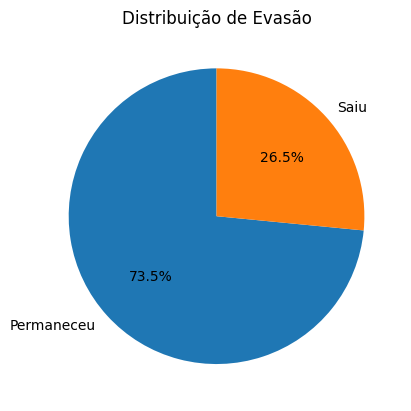

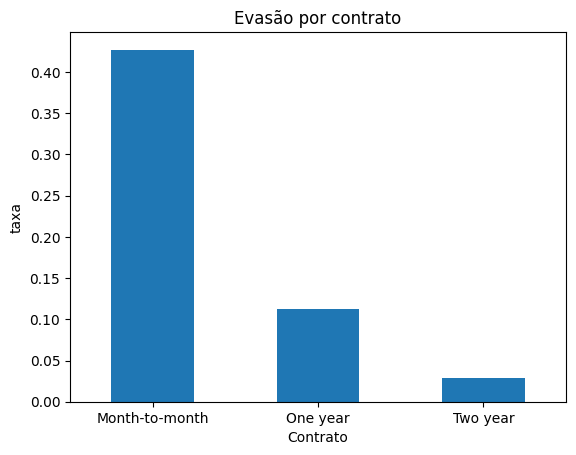

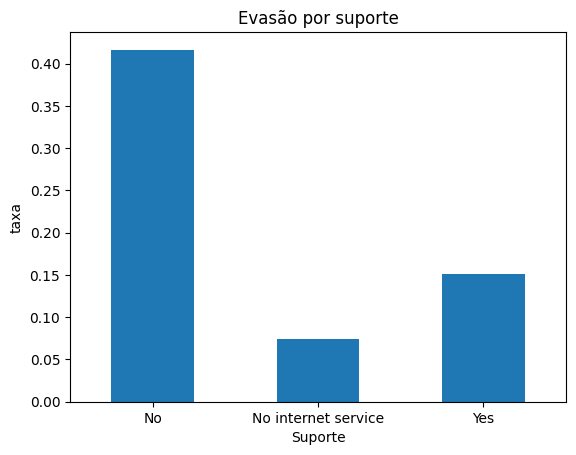

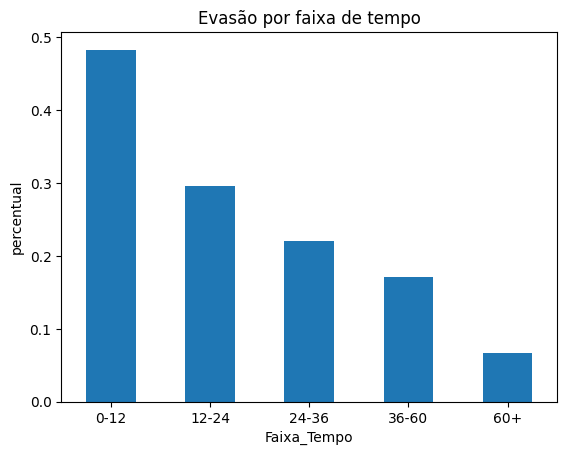

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/refs/heads/main/TelecomX_Data.json"
raw = pd.read_json(url)
df = pd.json_normalize(raw.to_dict(orient="records"))

print("shape inicial:", df.shape)

# limpeza
# churn vazio
df["Churn"] = df["Churn"].replace("", pd.NA)
df = df.dropna(subset=["Churn"])

# binario
df["Churn"] = df["Churn"].replace({"Yes": 1, "No": 0})

# valor numérico
df["account.Charges.Total"] = pd.to_numeric(
    df["account.Charges.Total"],
    errors="coerce"
).fillna(0)

print("shape após limpeza:", df.shape)

# escolhendo colunas Relevantes

df = df[
    [
        "Churn",
        "customer.gender",
        "customer.SeniorCitizen",
        "customer.tenure",
        "account.Contract",
        "account.PaymentMethod",
        "internet.TechSupport",
        "account.Charges.Monthly",
        "account.Charges.Total",
    ]
].copy()

df.columns = [
    "Churn",
    "Genero",
    "Idoso",
    "Meses",
    "Contrato",
    "Pagamento",
    "Suporte",
    "Mensal",
    "Total",
]


# ------------------------ Analises

print("\nTaxa geral de churn:")
print(df["Churn"].value_counts(normalize=True))

print("\nEvasão por contrato:")
churn_contrato = df.groupby("Contrato")["Churn"].mean()
print(churn_contrato)

print("\nEvasão por suporte:")
churn_suporte = df.groupby("Suporte")["Churn"].mean()
print(churn_suporte)

# tempo de contrato
bins = [0, 12, 24, 36, 60, np.inf]
labels = ["0-12", "12-24", "24-36", "36-60", "60+"]

df["Faixa_Tempo"] = pd.cut(
    df["Meses"],
    bins=bins,
    labels=labels,
    right=False,
)

tabela_tempo = pd.crosstab(
    df["Faixa_Tempo"],
    df["Churn"],
    normalize="index",
)

print("\nChurn por faixa de tempo:")
print(tabela_tempo)

print("\nMédia de Evasão mensal :")
print(df.groupby("Churn")["Meses"].mean())

print("\nMédia de gasto total de Evasão:")
print(df.groupby("Churn")["Total"].mean())

# -----------------------------------   gráficos  ---------------------------------

# distribuição geral
df["Churn"].value_counts(normalize=True).plot(
    kind="pie",
    autopct="%1.1f%%",
    labels=["Permaneceu", "Saiu"],
    startangle=90,
)
plt.ylabel("")
plt.title("Distribuição de Evasão")
plt.show()

# contrato
churn_contrato.plot(kind="bar")
plt.title("Evasão por contrato")
plt.ylabel("taxa")
plt.xticks(rotation=0)
plt.show()

# suporte
churn_suporte.plot(kind="bar")
plt.title("Evasão por suporte")
plt.ylabel("taxa")
plt.xticks(rotation=0)
plt.show()

# faixa de tempo
if 1 in tabela_tempo.columns:
    tabela_tempo[1].plot(kind="bar")
    plt.title("Evasão por faixa de tempo")
    plt.ylabel("percentual")
    plt.xticks(rotation=0)
    plt.show()


#📄Relatorio Final

📊 Relatório Analítico — Evasão de Clientes (Churn)
1. Visão Geral da Base de Dados

A base inicial continha 7.267 registros.
Após o processo de limpeza, a base final utilizada na análise ficou com 7.043 clientes válidos.

Taxa geral de evasão: 26,5%

Taxa de permanência: 73,5%

Isso indica que aproximadamente 1 em cada 4 clientes cancela o serviço, representando impacto relevante para o negócio.

2. Principais Fatores que Influenciam a Evasão
2.1 Tipo de Contrato

Taxa de evasão por contrato:

Contrato	Taxa de Churn
Month-to-month	42,7%
One year	11,3%
Two year	2,8%

O contrato mensal apresenta taxa de evasão significativamente superior.

Clientes com contrato mensal têm probabilidade muito maior de cancelamento quando comparados aos contratos anuais e bianuais.

📌 Este é o fator mais determinante identificado na análise.

2.2 Tempo de Permanência (Tenure)

Taxa de evasão por faixa de tempo:

Faixa de Tempo	% Churn
0–12 meses	48,3%
12–24 meses	29,5%
24–36 meses	22,0%
36–60 meses	17,1%
60+ meses	6,7%

Quase metade dos clientes com até 12 meses cancela o serviço.

Média de permanência de quem cancela: 17,9 meses

Média de permanência de quem permanece: 37,5 meses

Observa-se queda progressiva da evasão conforme o tempo aumenta.

📌 O período crítico está concentrado no primeiro ano.

2.3 Suporte Técnico

Taxa de evasão por suporte:

Suporte	Taxa de Churn
Sem suporte	41,6%
Com suporte	15,2%
Sem internet	7,4%

Clientes sem suporte técnico apresentam quase 3 vezes mais chance de evasão.

📌 A percepção de assistência e suporte impacta diretamente a retenção.

2.4 Análise Financeira

Média de gasto total:

Situação do Cliente	Gasto Médio Total
Permanece	2.549
Cancela	1.531

Clientes que cancelam acumulam menor valor total, principalmente porque permanecem menos tempo.

📌 A empresa perde clientes antes que eles se tornem altamente rentáveis.

3. Síntese dos Fatores Mais Determinantes

Com base na análise, os principais fatores que impactam a evasão são:

Contrato mensal

Baixo tempo de permanência (até 12 meses)

Ausência de suporte técnico

Baixo vínculo contratual

A evasão está concentrada em clientes com menor comprometimento e menor tempo de relacionamento com a empresa.

4. Estratégias de Retenção Propostas
4.1 Programa de Retenção no Primeiro Ano

Considerando que quase metade dos clientes até 12 meses cancela:

Contato ativo nos primeiros 90 dias

Pesquisa de satisfação no 3º e 6º mês

Benefícios de permanência ao completar 12 meses

Objetivo: reduzir evasão no período crítico inicial.

4.2 Incentivo à Migração para Contratos Anuais

Como contratos longos reduzem drasticamente o churn:

Desconto para migração de plano mensal para anual

Benefícios exclusivos para contratos de maior duração

Campanhas direcionadas aos clientes mensais

Objetivo: aumentar comprometimento e reduzir exposição ao cancelamento.

4.3 Ampliação do Suporte Técnico

Clientes sem suporte apresentam elevada taxa de evasão:

Oferecer suporte como diferencial competitivo

Criar pacotes promocionais com suporte incluso

Reforçar comunicação dos benefícios do suporte

Objetivo: aumentar percepção de valor e segurança no serviço.

4.4 Implementação de Modelo Preditivo

Utilizar variáveis como:

Tipo de contrato

Tempo de permanência

Suporte técnico

Valor mensal

Para criar um score de risco de evasão, permitindo ações preventivas antes do cancelamento.

5. Conclusão

A evasão de clientes não ocorre de forma aleatória. Ela está concentrada principalmente em:

Clientes com contrato mensal

Clientes nos primeiros 12 meses

Clientes sem suporte técnico

A empresa deve concentrar esforços na retenção inicial e na conversão para contratos de maior duração.

Reduzir o churn nos primeiros meses pode gerar impacto significativo na receita e no valor de longo prazo da base de clientes.
